In [50]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from os.path import join, exists
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler, WeightedRandomSampler
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, DatasetFolder
!pip install torchinfo
import torchinfo

# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [51]:
from google.colab import drive
drive.mount('/content/drive')

# get data and unzip (if not already)
if not exists('data_cleaned'):
  !unzip "/content/drive/My Drive/aps360/project_data"
else:
  print('Data already loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already loaded


In [52]:
BASE_DATA_PATH = 'data_cleaned'
IMAGE_PATH = join(BASE_DATA_PATH, 'images')
ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')

In [53]:
df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'))
n = len(df)
value_counts = df['label'].value_counts()
print(f"Total Samples: {n}")
print(value_counts)

Total Samples: 21747
label
no finding           7932
pneumonia            4722
other                1477
heart disease        1088
infiltration         1088
consolidation        1088
effusion             1088
bronchiolitis        1088
bronchitis           1088
broncho-pnuemonia    1088
Name: count, dtype: int64


In [54]:
## NOTE: UPDATE IMAGE SIZES TO BE 130x100 OR ELSE
## DOES NOT FIT INTO LOCAL OR COLAB RAM

from skimage import io
from skimage.transform import resize
from copy import deepcopy

df_new = deepcopy(df)
# DESIRED_IMG_SIZE = (520,400)
DESIRED_IMG_SIZE = (130, 100)

save_folder = 'data_small'
if not exists(save_folder):
  os.makedirs(save_folder)

for i in tqdm(range(len(df))):
  row = df.iloc[i]
  fname = row['filename']
  # load image
  img_path = os.path.join(IMAGE_PATH, fname)
  img = Image.open(img_path).convert('L')
  img = np.array(img)
  scaled_x = DESIRED_IMG_SIZE[0] / img.shape[0]
  scaled_y = DESIRED_IMG_SIZE[1] / img.shape[1]
  if not exists(join(save_folder, fname)):
    # resize
    img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
    img_resized = (img_resized * 255).astype(np.uint8)
    # save
    save_path = join(save_folder, fname)
    Image.fromarray(img_resized).save(save_path)

  # update bbox in df_new if needed
  if row['has bbox']:
    df_new.at[i, 'min_x'] = row['min_x'] * scaled_x
    df_new.at[i, 'min_y'] = row['min_y'] * scaled_y
    df_new.at[i, 'width'] = row['width'] * scaled_x
    df_new.at[i, 'height'] = row['height'] * scaled_y

100%|██████████| 21747/21747 [00:35<00:00, 619.58it/s]


In [55]:
# BASE_DATA_PATH = '/home/orrin/aps360/pediatric-cxr-model/data_cleaned'
# IMAGE_PATH = join(BASE_DATA_PATH, 'images')
IMAGE_PATH = join(save_folder)
df_new.to_csv('master_alternate_augmented_small.csv', index=False)
# ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')
ANNOT_PATH = os.path.curdir

In [56]:
# define custom dataset
class CXRClassificationDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.data = pd.read_csv(csv_file)
        # Encode labels as integers
        self.label_encoder = LabelEncoder()
        self.data['label_encoded'] = self.label_encoder.fit_transform(self.data['label'])
        self.label_decoder = {i: label for i, label in enumerate(self.label_encoder.classes_)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = join(self.image_dir, self.data.iloc[idx]['filename'])
        image = Image.open(img_name).convert('L')  # convert to grayscale
        label = self.data.iloc[idx]['label_encoded']
        if self.transform:
            image = self.transform(image)
        return image, label

In [57]:
def ConvBlock(in_channels, out_channels, kernel_size=3, stride=1, padding=1, dropout=0.2):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.SiLU(inplace=True),
        nn.BatchNorm2d(out_channels),
        nn.Dropout2d(dropout)
    )

def FeedForwardBlock(in_features, out_features, dropout=0.2):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
        nn.SiLU(inplace=True),
        nn.BatchNorm1d(out_features),
        nn.Dropout(dropout)
    )

def FeedForwardLastLayer(in_features, out_features):
    return nn.Sequential(
        nn.Linear(in_features, out_features),
    )

class ComposableCNN(nn.Module):
    def __init__(self, conv_params):
        super(ComposableCNN, self).__init__()
        self.params = conv_params
        self.n_conv_layers = len(conv_params)

        for i, (in_ch, out_ch, k, s, p, d) in enumerate(conv_params):
            setattr(self, f'block{i+1}', ConvBlock(in_ch, out_ch, k, s, p, d))

    def forward(self, x):
        for i in range(1, self.n_conv_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class ComposableFFN(nn.Module):
    def __init__(self, fc_params):
        super(ComposableFFN, self).__init__()
        self.params = fc_params
        self.n_ff_layers = len(fc_params)

        for i, (in_ch, out_ch, d) in enumerate(fc_params):
            if i == self.n_ff_layers - 1:
                setattr(self, f'block{i+1}', FeedForwardLastLayer(in_ch, out_ch))
            else:
                setattr(self, f'block{i+1}', FeedForwardBlock(in_ch, out_ch, d))

    def forward(self, x):
        for i in range(1, self.n_ff_layers + 1):
            block = getattr(self, f'block{i}')
            x = block(x)
        return x

class PediatricCXRClassificationModel(nn.Module):
    def __init__(self, name, conv_params, fc_params):
        super(PediatricCXRClassificationModel, self).__init__()
        self.name = name
        self.cnn = ComposableCNN(conv_params)
        self.ffn = ComposableFFN(fc_params)

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.ffn(x)
        return x

In [58]:
# Define convolutional parameters for a deeper five-layer CNN with larger kernels
# (in_channels, out_channels, kernel_size, stride, padding, dropout)
conv_params = [
    (1, 8, 5, 2, 2, 0.2),   # Input: (1, 130, 100) -> Output: (8, 65, 50) using kernel 5
    (8, 16, 3, 2, 1, 0.2),  # Input: (8, 65, 50) -> Output: (16, 33, 25)
    (16, 32, 5, 2, 2, 0.2), # Input: (16, 33, 25) -> Output: (32, 17, 13) using kernel 5
    (32, 64, 3, 2, 1, 0.2), # Input: (32, 17, 13) -> Output: (64, 9, 7)
    (64, 128, 3, 2, 1, 0.2) # Input: (64, 9, 7) -> Output: (128, 5, 4)
]

# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 128
# Last CNN layer output height: 5
# Last CNN layer output width: 4
ffn_input_size = 128 * 5 * 4 # This is 2560

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 16, 0.5), # First hidden layer
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('deeper_larger_kernels', conv_params, fc_params)
torchinfo.summary(model, input_size=(1, 1, 130, 100))

Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 10]                   --
├─ComposableCNN: 1-1                     [1, 128, 5, 4]            --
│    └─Sequential: 2-1                   [1, 8, 65, 50]            --
│    │    └─Conv2d: 3-1                  [1, 8, 65, 50]            208
│    │    └─SiLU: 3-2                    [1, 8, 65, 50]            --
│    │    └─BatchNorm2d: 3-3             [1, 8, 65, 50]            16
│    │    └─Dropout2d: 3-4               [1, 8, 65, 50]            --
│    └─Sequential: 2-2                   [1, 16, 33, 25]           --
│    │    └─Conv2d: 3-5                  [1, 16, 33, 25]           1,168
│    │    └─SiLU: 3-6                    [1, 16, 33, 25]           --
│    │    └─BatchNorm2d: 3-7             [1, 16, 33, 25]           32
│    │    └─Dropout2d: 3-8               [1, 16, 33, 25]           --
│    └─Sequential: 2-3                   [1, 32, 17, 13]           --
│    │    └

In [88]:
# Define convolutional parameters for a five-layer CNN
# (in_channels, out_channels, kernel_size, stride, padding, dropout)
conv_params = [
    (1, 4, 3, 2, 1, 0.2),   # Input: (1, 130, 100) -> Output: (4, 65, 50)
    (4, 8, 3, 2, 1, 0.2),  # Input: (4, 65, 50) -> Output: (8, 33, 25)
    (8, 16, 3, 2, 1, 0.2),  # Input: (8, 33, 25) -> Output: (16, 17, 13)
    (16, 32, 3, 2, 1, 0.2), # Input: (16, 17, 13) -> Output: (32, 9, 7)
    (32, 64, 3, 2, 1, 0.2) # Input: (32, 9, 7) -> Output: (64, 5, 4)
]

# Calculate the input size for the feedforward network based on CNN output
# Last CNN layer output channels: 64
# Last CNN layer output height: 5
# Last CNN layer output width: 4
ffn_input_size = 64 * 5 * 4 # This is 1280 (64 * 5 * 4)

# Define feedforward parameters for a two-layer FFN
# (in_features, out_features, dropout)
fc_params = [
    (ffn_input_size, 16, 0.5), # First hidden layer
    (16, 10, 0.0) # Output layer for 10 classes (dropout not applied to output)
]

# Create the PediatricCXRClassificationModel
model = PediatricCXRClassificationModel('initial', conv_params, fc_params)
torchinfo.summary(model, input_size=(1, 1, 130, 100))

Layer (type:depth-idx)                   Output Shape              Param #
PediatricCXRClassificationModel          [1, 10]                   --
├─ComposableCNN: 1-1                     [1, 64, 5, 4]             --
│    └─Sequential: 2-1                   [1, 4, 65, 50]            --
│    │    └─Conv2d: 3-1                  [1, 4, 65, 50]            40
│    │    └─SiLU: 3-2                    [1, 4, 65, 50]            --
│    │    └─BatchNorm2d: 3-3             [1, 4, 65, 50]            8
│    │    └─Dropout2d: 3-4               [1, 4, 65, 50]            --
│    └─Sequential: 2-2                   [1, 8, 33, 25]            --
│    │    └─Conv2d: 3-5                  [1, 8, 33, 25]            296
│    │    └─SiLU: 3-6                    [1, 8, 33, 25]            --
│    │    └─BatchNorm2d: 3-7             [1, 8, 33, 25]            16
│    │    └─Dropout2d: 3-8               [1, 8, 33, 25]            --
│    └─Sequential: 2-3                   [1, 16, 17, 13]           --
│    │    └─Con

In [60]:
csv_file = join(ANNOT_PATH, 'master_alternate_augmented_small.csv')
# csv_file = join(ANNOT_PATH, 'master_alternate_augmented.csv')
dataset = CXRClassificationDataset(
    csv_file=csv_file,
    image_dir=IMAGE_PATH,
    transform=transforms.ToTensor()
)

In [81]:
# helper funtion to split train, validation, and test sets and get loaders
# includes utility to get a certain percentage of the data (useful for question 2c)
def get_data_loaders(
    data,
    percent_train,
    percent_validation,
    percent_test,
    batch_size,
    percent_data=1.0,
    use_weighted_sampler=False):
    # Ensure splits add up to one
    assert percent_train + percent_validation + percent_test == 1.0, \
    "Split percentages must add up to 1.0"

    # set seed to always get same loaders
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Get indices for the entire dataset
    full_indices = list(range(len(data)))

    # Randomly select a percentage of the data's indices
    selected_indices = np.random.choice(full_indices, int(len(data) * percent_data), replace=False)

    # Get labels for the selected indices to use for stratification
    selected_labels = [data.data['label_encoded'].iloc[i] for i in selected_indices]

    # Split the selected_indices into training, validation, and testing indices with stratification
    train_indices, validate_test_indices, _, validate_test_labels = train_test_split(
        selected_indices, selected_labels, train_size=percent_train, random_state=seed, stratify=selected_labels)

    validate_indices, test_indices, _, _ = train_test_split(
        validate_test_indices, validate_test_labels, train_size=percent_validation/(percent_validation+percent_test), random_state=seed, stratify=validate_test_labels)

    # Create Subset objects using the original dataset and the split indices
    data_train = Subset(data, train_indices)
    data_validate = Subset(data, validate_indices)
    data_test = Subset(data, test_indices)

    print("Train Size:", len(data_train))
    print("Validation Size:", len(data_validate))
    print("Test Size:", len(data_test))

    # Verify all 10 classes are present in each split
    train_classes = set([data_train.dataset.data['label_encoded'].iloc[i] for i in data_train.indices])
    val_classes = set([data_validate.dataset.data['label_encoded'].iloc[i] for i in data_validate.indices])
    test_classes = set([data_test.dataset.data['label_encoded'].iloc[i] for i in data_test.indices])
    all_classes = set(range(len(data.label_encoder.classes_)))

    if not (all_classes.issubset(train_classes) and all_classes.issubset(val_classes) and all_classes.issubset(test_classes)):
        print("Warning: Not all 10 classes are present in all splits. Consider increasing percent_data or checking data distribution.")
        print(f"Missing in train: {all_classes - train_classes}")
        print(f"Missing in validation: {all_classes - val_classes}")
        print(f"Missing in test: {all_classes - test_classes}")

    # get class distribution in each loader
    if use_weighted_sampler:
        # Get all labels from the training subset. Now data_train is a Subset object.
        train_labels = [data_train.dataset.data['label_encoded'].iloc[i] for i in data_train.indices]
        class_counts = Counter(train_labels)
        # Create a list of weights for each sample
        num_classes = len(data.label_encoder.classes_)
        class_weights = [0.] * num_classes
        for i in range(num_classes):
            class_weights[i] = 1.0 / class_counts[i] if class_counts[i] > 0 else 0.

        sample_weights = [class_weights[label] for label in train_labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        loader_train = DataLoader(data_train, batch_size=batch_size, sampler=sampler)
    else:
        loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True)

    loader_validate = DataLoader(data_validate, batch_size=batch_size, shuffle=True)
    loader_test = DataLoader(data_test, batch_size=batch_size, shuffle=True)

    return loader_train, loader_validate, loader_test

def get_data_loaders_old(
    data,
    percent_train,
    percent_validation,
    percent_test,
    batch_size,
    percent_data=1.0):
  # Ensure splits add up to one
  assert percent_train + percent_validation + percent_test == 1.0, \
    "Split percentages must add up to 1.0"

  # randomly define data to use based on percent
  indices = np.random.choice(len(data), int(len(data) * percent_data))
  data_to_use = Subset(data, indices)

  # load splits
  data_train, data_validate_test = train_test_split(data_to_use, train_size=percent_train,
                                                    shuffle=True)
  data_validate, data_test = train_test_split(data_validate_test, \
      train_size=percent_validation/(percent_validation+percent_test),
                                              shuffle=True)
  print("Train Size:", len(data_train))
  print("Validation Size:", len(data_validate))
  print("Test Size:", len(data_test))

  # create dataloaders
  loader_train = DataLoader(data_train, batch_size=batch_size, shuffle=True)
  loader_validate = DataLoader(data_validate, batch_size=batch_size, shuffle=True)
  loader_test = DataLoader(data_test, batch_size=batch_size, shuffle=True)

  return loader_train, loader_validate, loader_test

In [83]:
# Functions based off of Lab 2: Cat and Dogs
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path


def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
     # set up variables
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    if torch.cuda.is_available():
      net = net.cuda()
    net.eval() # turn off dropout

    # compute correct predictions and loss for each batch
    # save samples for future accuracy prediction
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        if torch.cuda.is_available():
            inputs = inputs.cuda()
            labels = labels.cuda()

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        corr = torch.eq(outputs.argmax(1), labels).sum().item()
        total_correct += corr
        total_loss += loss.item()
        total_samples += outputs.shape[0]

    # compute total accuracy and total loss
    accuracy = float(total_correct) / total_samples
    loss = float(total_loss) / (len(loader))
    return accuracy, loss


def train_net(net,
              train_loader,
              val_loader,
              batch_size=32,
              learning_rate=0.01,
              num_epochs=30,
              checkpoint_freq=20,
              use_weighted_loss=False):

    if torch.cuda.is_available():
      net = net.cuda()
    net.train() # put model into training mode
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Cross Entropy Loss.
    # Optimizer will be SGD with Momentum.

    criterion = None
    if use_weighted_loss:
      # weight cross entropy loss to reduce class imbalance
      all_labels = [
          label for _, label in train_loader.dataset
      ]
      class_counts = Counter(all_labels)
      class_weights = [1.0 / count for count in class_counts.values()]
      class_weights = torch.tensor(class_weights).float()
      if torch.cuda.is_available():
          class_weights = class_weights.cuda()
      criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
      criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_acc = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_acc = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):
        total_train_loss = 0.0
        total_train_correct = 0
        total_samples = 0

        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            if torch.cuda.is_available():
                inputs = inputs.cuda()
                labels = labels.cuda()

            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Calculate the statistics
            corr = torch.eq(outputs.argmax(1), labels).sum().item()
            total_train_correct += corr
            total_samples += outputs.shape[0]
            total_train_loss += loss.item()

        train_acc[epoch] = float(total_train_correct) / total_samples
        train_loss[epoch] = float(total_train_loss) / len(train_loader)
        val_acc[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train Accuracy: {}, Train loss: {} |"+
               "Validation Accuracy: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_acc[epoch],
                   train_loss[epoch],
                   val_acc[epoch],
                   val_loss[epoch]))

        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        if epoch % checkpoint_freq == 0:
            torch.save(net.state_dict(), model_path)

    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    np.savetxt("{}_train_acc.csv".format(model_path), train_acc)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_acc.csv".format(model_path), val_acc)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_acc = np.loadtxt("{}_train_acc.csv".format(path))
    val_acc = np.loadtxt("{}_val_acc.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Accuracy")
    n = len(train_acc) # number of epochs
    plt.plot(range(1,n+1), train_acc, label="Train")
    plt.plot(range(1,n+1), val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

def pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=10,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_sampler=False,
    use_weighted_loss=False,
):
    # get data loaders
    loader_train, loader_validate, loader_test = get_data_loaders(
        dataset,
        percent_train=percent_train,
        percent_validation=percent_validation,
        percent_test=percent_test,
        batch_size=batch_size,
        percent_data=percent_data,
        use_weighted_sampler=use_weighted_sampler
    )

    # train model
    train_net(model,
              loader_train,
              loader_validate,
              batch_size=batch_size,
              learning_rate=learning_rate,
              num_epochs=num_epochs,
              checkpoint_freq=checkpoint_freq,
              use_weighted_loss=use_weighted_loss)

def pipeline_old_loader(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=10,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_loss=False,
):
    # get data loaders
    loader_train, loader_validate, loader_test = get_data_loaders_old(
        dataset,
        percent_train=percent_train,
        percent_validation=percent_validation,
        percent_test=percent_test,
        batch_size=batch_size,
        percent_data=percent_data,
    )

    # train model
    train_net(model,
              loader_train,
              loader_validate,
              batch_size=batch_size,
              learning_rate=learning_rate,
              num_epochs=num_epochs,
              checkpoint_freq=checkpoint_freq,
              use_weighted_loss=use_weighted_loss)

In [63]:
# overfit on subset
pipeline(
    model,
    dataset,
    batch_size=32,
    learning_rate=0.01,
    num_epochs=100,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=0.05,
    checkpoint_freq=1,
    use_weighted_sampler=True,
    use_weighted_loss=True
)

Train Size: 760
Validation Size: 163
Test Size: 164
Epoch 1: Train Accuracy: 0.16973684210526316, Train loss: 2.279470682144165 |Validation Accuracy: 0.049079754601226995, Validation loss: 2.034719546635946
Epoch 2: Train Accuracy: 0.1736842105263158, Train loss: 2.095906679828962 |Validation Accuracy: 0.4171779141104294, Validation loss: 1.7967461148897808
Epoch 3: Train Accuracy: 0.3144736842105263, Train loss: 1.68109330534935 |Validation Accuracy: 0.5398773006134969, Validation loss: 1.3951881329218547
Epoch 4: Train Accuracy: 0.3631578947368421, Train loss: 1.552616039911906 |Validation Accuracy: 0.4662576687116564, Validation loss: 1.3132165869077046
Epoch 5: Train Accuracy: 0.4105263157894737, Train loss: 1.324033722281456 |Validation Accuracy: 0.3803680981595092, Validation loss: 1.8593764106432598
Epoch 6: Train Accuracy: 0.5, Train loss: 1.1902435248096783 |Validation Accuracy: 0.3619631901840491, Validation loss: 1.7570416927337646
Epoch 7: Train Accuracy: 0.5763157894736842

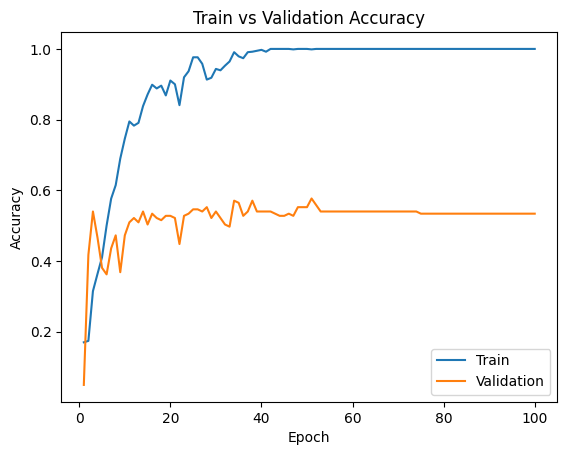

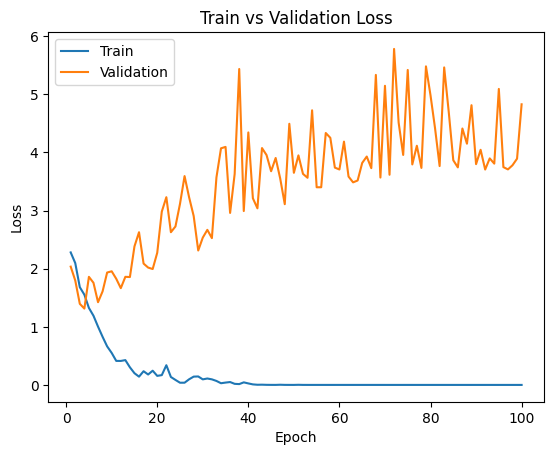

In [64]:
path = get_model_name(model.name, 32, 0.01, 99)
plot_training_curve(path)

In [66]:
pipeline(
    model,
    dataset,
    batch_size=128,
    learning_rate=0.0005,
    num_epochs=200,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=1.0,
    checkpoint_freq=1,
    use_weighted_sampler=False,
    use_weighted_loss=True,
)

Train Size: 15222
Validation Size: 3262
Test Size: 3263
Epoch 1: Train Accuracy: 0.33563263697280254, Train loss: 2.2093039400437298 |Validation Accuracy: 0.5334150827713059, Validation loss: 1.4831939247938304
Epoch 2: Train Accuracy: 0.570227302588359, Train loss: 1.3586864381277262 |Validation Accuracy: 0.5861434702636419, Validation loss: 1.3126787543296814
Epoch 3: Train Accuracy: 0.5861253448955459, Train loss: 1.2695828305573023 |Validation Accuracy: 0.5910484365419988, Validation loss: 1.2684189356290376
Epoch 4: Train Accuracy: 0.5907239521744843, Train loss: 1.225044355172069 |Validation Accuracy: 0.5944206008583691, Validation loss: 1.2312787541976342
Epoch 5: Train Accuracy: 0.5929575614242544, Train loss: 1.19179798274481 |Validation Accuracy: 0.5980993255671367, Validation loss: 1.1945485060031598
Epoch 6: Train Accuracy: 0.59551964262252, Train loss: 1.1650978697448218 |Validation Accuracy: 0.6011649294911098, Validation loss: 1.1763693323502173
Epoch 7: Train Accuracy: 

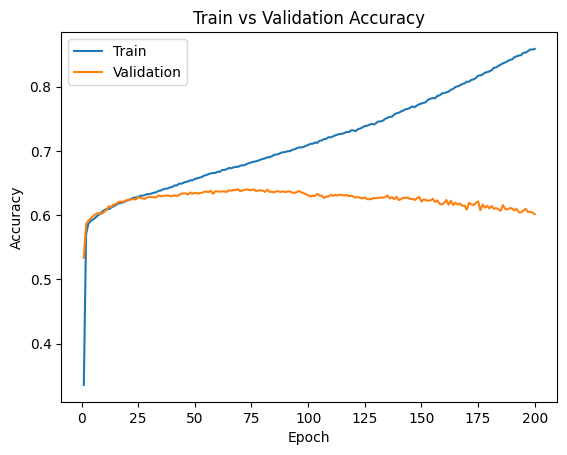

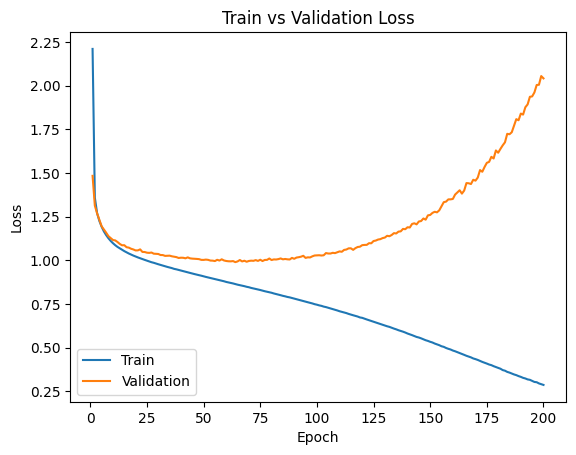

In [68]:
path = get_model_name(model.name, 128, 0.0005, 199)
plot_training_curve(path)

In [89]:
pipeline_old_loader(
    model,
    dataset,
    batch_size=128,
    learning_rate=0.0005,
    num_epochs=200,
    percent_train=0.7,
    percent_validation=0.15,
    percent_test=0.15,
    percent_data=1.0,
    checkpoint_freq=1,
    use_weighted_loss=False,
)

Train Size: 15222
Validation Size: 3262
Test Size: 3263
Epoch 1: Train Accuracy: 0.22703981080015767, Train loss: 2.272281713846351 |Validation Accuracy: 0.5278969957081545, Validation loss: 1.7602465061041026
Epoch 2: Train Accuracy: 0.5656943896991197, Train loss: 1.4077872799224211 |Validation Accuracy: 0.5797057020232986, Validation loss: 1.3211435354672945
Epoch 3: Train Accuracy: 0.6006438050190513, Train loss: 1.2152806395242195 |Validation Accuracy: 0.5980993255671367, Validation loss: 1.2171091116391695
Epoch 4: Train Accuracy: 0.6236368414137433, Train loss: 1.1314664347832943 |Validation Accuracy: 0.6146535867565911, Validation loss: 1.1605750757914324
Epoch 5: Train Accuracy: 0.637761135199054, Train loss: 1.0823068874222892 |Validation Accuracy: 0.6167995095033721, Validation loss: 1.1502498640463903
Epoch 6: Train Accuracy: 0.6481408487715149, Train loss: 1.044499477418531 |Validation Accuracy: 0.6210913549969344, Validation loss: 1.1202138524789076
Epoch 7: Train Accurac

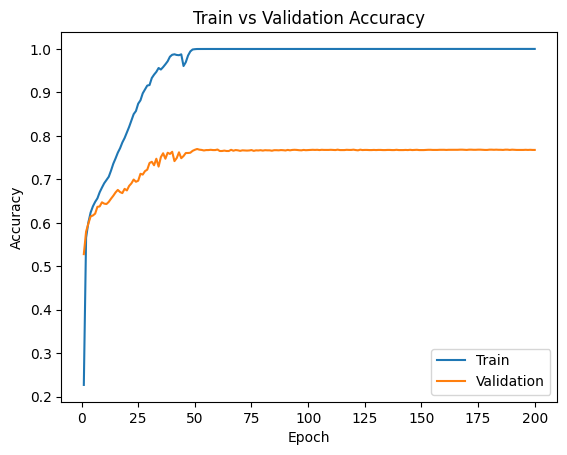

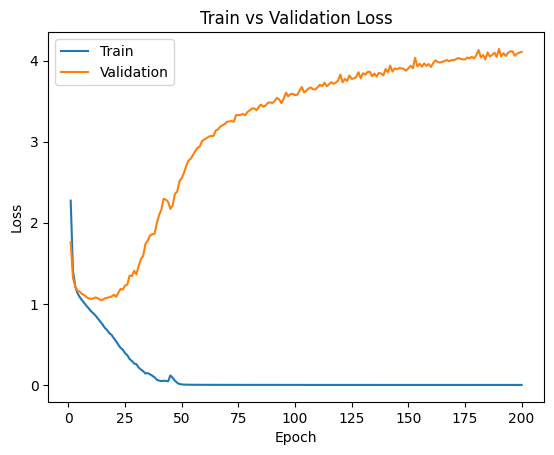

In [90]:
path = get_model_name(model.name, 128, 0.0005, 199)
plot_training_curve(path)